In [13]:
!python3 -m pip install motornet

In [14]:
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import motornet as mn
from typing import Any
from IPython import get_ipython

Matplotlib is building the font cache; this may take a moment.


In [15]:
print('All packages imported.')
print('pytorch. version: ' + torch.__version__)
print('numpy version: ' + np.__version__)
print('motornet version: ' + mn.__version__)

All packages imported.
pytorch. version: 2.13.0
numpy version: 2.4.6
motornet version: 0.3.0


## Creating custom centre-out environment

In [16]:
import numpy as np
import torch
import motornet as mn


class CentreOutReach(mn.environment.Environment):

    def __init__(self, *args, n_directions: int = 8, catch_trial_perc: float = 0.2,
                 reaching_distance: float = 0.10, center_position=None,
                 go_cue_range=(0.2, 0.4), **kwargs):
        super().__init__(*args, **kwargs)

        self.__name__ = "centre_out_reach"

        self.n_directions = int(n_directions)
        self.catch_trial_perc = float(catch_trial_perc)
        self.reaching_distance = float(reaching_distance)
        self.go_cue_range = go_cue_range

        self.center_position = center_position

        # fixed angular grid (rad) or directions
        self.directions = np.linspace(0.0, 2 * np.pi, self.n_directions, endpoint=False)

        # per-trial bookkeeping, (re)set in reset(), read/updated in step()
        self.center_xy = None     # (batch, 2) tensor
        self.target_xy = None     # (batch, 2) tensor
        self.is_catch = None      # (batch,) bool numpy array
        self.go_cue_time = None   # (batch,) float numpy array

    # ------------------------------------------------------------------ #
    def reset(self, *, seed: int = None, options: dict = None):
        # Seeds this Environment's own PRNG (self.np_random) *and* seeds the
        # attached effector with a derived seed. Always call this first.
        self._set_generator(seed)

        options = {} if options is None else options
        batch_size: int = options.get("batch_size", 1)
        joint_state = options.get("joint_state", None)
        deterministic: bool = options.get("deterministic", False)
        # our own custom option, not known to the base Environment class
        direction_idx = options.get("direction_idx", None)

        # fall back to the fixed centre posture if the caller didn't override it
        if joint_state is None and self.center_position is not None:
            joint_state = self.effector.draw_fixed_states(
                batch_size=batch_size, position=self.center_position
            )
        # if both joint_state and self.center_position are None, joint_state stays
        # None here, and Effector.reset() will draw an independent random posture


        self.effector.reset(options={"batch_size": batch_size, "joint_state": joint_state})

        # centre = fingertip position immediately after landing on the start posture
        center_xy = self.states["fingertip"]
        center_xy = center_xy if self.differentiable else self.detach(center_xy)


        if direction_idx is not None:
          idx = np.atleast_1d(np.asarray(direction_idx)) % self.n_directions
          if idx.size == 1 and batch_size > 1:
             idx = np.repeat(idx, batch_size)
        else:
           idx = self.np_random.integers(low=0, high=self.n_directions, size=batch_size)
        angles = self.directions[idx]

        angles_t = torch.as_tensor(angles, dtype=center_xy.dtype, device=self.device).unsqueeze(-1)
        direction_xy = torch.cat([torch.cos(angles_t), torch.sin(angles_t)], dim=-1)
        target_xy = center_xy + self.reaching_distance * direction_xy

        # --- catch trials & go-cue timing ---

        if direction_idx is not None:
            is_catch = np.zeros(batch_size, dtype=bool)

        else:
            is_catch = self.np_random.uniform(size=batch_size) < self.catch_trial_perc
        go_cue_time = self.go_cue_range



        self.center_xy = center_xy
        self.target_xy = target_xy
        self.is_catch = is_catch
        self.go_cue_time = go_cue_time
        self.elapsed = 0.0
        self.direction_idx = idx

        # at trial onset the goal is simply to hold at the centre
        self.goal = center_xy.clone() if self.differentiable else center_xy.copy()

        action = torch.zeros((batch_size, self.muscle.n_muscles)).to(self.device)
        self.obs_buffer["proprioception"] = [self.get_proprioception()] * len(self.obs_buffer["proprioception"])
        self.obs_buffer["vision"] = [self.get_vision()] * len(self.obs_buffer["vision"])
        self.obs_buffer["action"] = [action] * self.action_frame_stacking

        obs = self.get_obs(deterministic=deterministic)
        info = {
            "states": self.states,
            "action": action,
            "noisy action": action,
            "goal": self.goal,
            "direction_idx": idx,
            "centre": center_xy,
            "target": target_xy,
            "is_catch": is_catch,
            "go_cue_time": go_cue_time,
        }
        return obs, info

    # ------------------------------------------------------------------ #
    def step(self, action, deterministic: bool = False):
        self.elapsed += self.dt

        if deterministic is False:
            noisy_action = self.apply_noise(action, noise=self.action_noise)
        else:
            noisy_action = action

        self.effector.step(noisy_action)

        # --- update the goal: hold at centre until go cue, then jump to target ---
        went_live = (self.elapsed >= self.go_cue_time) & (~self.is_catch)  # (batch,) bool
        went_live_t = torch.as_tensor(
            went_live.astype(np.float32), dtype=self.center_xy.dtype, device=self.device
        ).unsqueeze(-1)
        self.goal = went_live_t * self.target_xy + (1.0 - went_live_t) * self.center_xy

        obs = self.get_obs(action=noisy_action, deterministic=deterministic)
        reward = None
        truncated = False
        terminated = bool(self.elapsed >= self.max_ep_duration)
        info = {
            "states": self.states,
            "action": action,
            "noisy action": noisy_action,
            "goal": self.goal,
            "went_live": went_live,
        }
        return obs, reward, terminated, truncated, info



### Effector and Envrionment Instances

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
effector = mn.effector.ReluPointMass24()

effector.to(device)
effector.muscle.to(device)
effector.skeleton.to(device)

env = CentreOutReach(
    effector=effector,
    n_directions=8,
    catch_trial_perc=0.37,
    reaching_distance=0.08,
    center_position= [0,0],
    go_cue_range=0.3,
    max_ep_duration=5,
)

env.to(device)
env.effector.to(device)
env.effector.muscle.to(device)
env.effector.skeleton.to(device)

PointMass()

In [19]:
env.print_attributes()

T_destination:  ~T_destination
action_frame_stacking:  0
action_noise:  [0.0, 0.0, 0.0, 0.0]
action_space:  Box(0.0, 1.0, (4,), float32)
call_super_init:  False
catch_trial_perc:  0.37
center_position:  [0, 0]
center_xy:  None
delay_range:  [0, 0]
device:  cpu
differentiable:  True
directions:  [0.         0.78539816 1.57079633 2.35619449 3.14159265 3.92699082
 4.71238898 5.49778714]
dt:  0.01
dump_patches:  False
elapsed:  None
go_cue_range:  0.3
go_cue_time:  None
goal:  None
is_catch:  None
max_ep_duration:  5
metadata:  {'render_modes': []}
n_directions:  8
n_muscles:  4
np_random:  Generator(PCG64)
np_random_seed:  189597239994523879022216448537072939331
nq_init:  None
obs_buffer:  {'proprioception': [None], 'vision': [None], 'action': []}
obs_noise:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
observation_space:  Box(-inf, inf, (12,), float32)
proprioception_delay:  1
proprioception_noise:  [0.0]
q_init:  None
reaching_distance:  0.08
render_mode:  None
seed:  No

### checking Task correctness

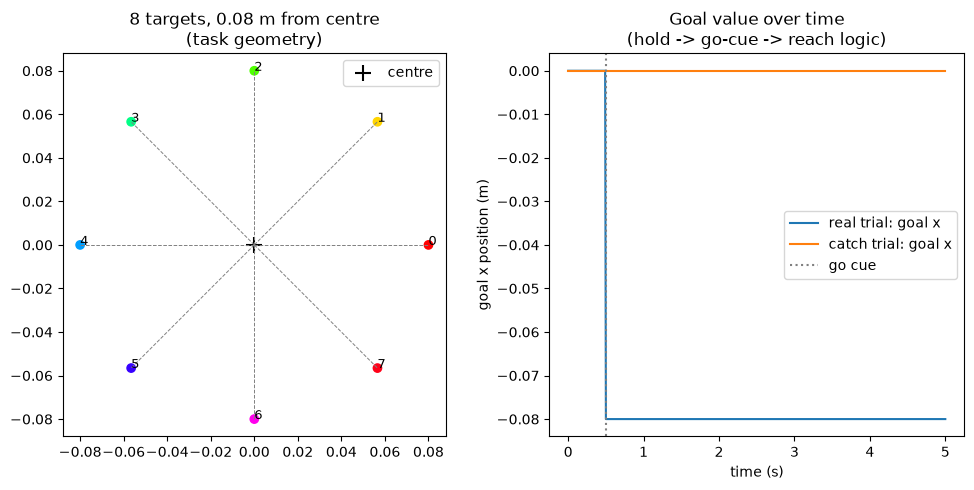

In [20]:
# ============================================================
# BEFORE-TRAINING sanity check: is the TASK itself correct?
# ============================================================


n_dirs = env.n_directions

# geometry check: are the 8 targets evenly spaced around one shared centre?



obs, info = env.reset(options={
    "batch_size": n_dirs,
    "direction_idx": np.arange(n_dirs),
    "deterministic": True,
})


centre = info["centre"].detach().cpu().numpy()
target = info["target"].detach().cpu().numpy()

# timing check: force one real trial + one catch trial, see how self.goal behaves
obs2, info2 = env.reset(options={"batch_size": 2, "deterministic": True})
env.is_catch = np.array([False,True])
env.go_cue_time = np.array([0.5, 1.5])

n_steps = int(round(env.max_ep_duration / env.dt))
goal_trace = [env.goal.detach().cpu().numpy().copy()]
for _ in range(n_steps):
    zero_action = torch.zeros(2, env.n_muscles, device=device)
    obs2, reward, terminated, truncated, info2 = env.step(zero_action, deterministic=True)
    goal_trace.append(env.goal.detach().cpu().numpy().copy())
    if terminated:
        break
goal_trace = np.stack(goal_trace, axis=0)  # (time, 2, 2)
times = np.arange(goal_trace.shape[0]) * env.dt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
ax.scatter(*centre[0], c="k", marker="+", s=120, label="centre")
ax.scatter(target[:, 0], target[:, 1], c=range(n_dirs), cmap="hsv")
for k in range(n_dirs):
    ax.plot([centre[0, 0], target[k, 0]], [centre[0, 1], target[k, 1]], "--", c="gray", lw=0.7)
    ax.annotate(str(k), target[k], fontsize=9)
ax.set_aspect("equal")
ax.set_title(f"{n_dirs} targets, {env.reaching_distance} m from centre\n(task geometry)")
ax.legend()

ax = axes[1]
ax.plot(times, goal_trace[:, 0, 0], label="real trial: goal x")
ax.plot(times, goal_trace[:, 1, 0], label="catch trial: goal x")
ax.axvline(env.go_cue_time[0], ls=":", c="gray", label="go cue")
ax.set_xlabel("time (s)")
ax.set_ylabel("goal x position (m)")
ax.set_title("Goal value over time\n(hold -> go-cue -> reach logic)")
ax.legend()

plt.tight_layout()
plt.show()

### Implementing our Policy(i.e the Gated Reccurent Unit)

In [21]:
class Policy(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, device):
        super().__init__()
        self.device = device
        self.hidden_dim = hidden_dim
        self.n_layers = 1

        self.gru = nn.GRU(input_dim, hidden_dim, 1, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

        # the default initialization in torch isn't ideal
        for name, param in self.named_parameters():
            if name == "gru.weight_ih_l0":
                nn.init.xavier_uniform_(param)
            elif name == "gru.weight_hh_l0":
                nn.init.orthogonal_(param)
            elif name == "gru.bias_ih_l0":
                nn.init.zeros_(param)
            elif name == "gru.bias_hh_l0":
                nn.init.zeros_(param)
            elif name == "fc.weight":
                nn.init.xavier_uniform_(param)
            elif name == "fc.bias":
                nn.init.constant_(param, -5.)
            else:
                raise ValueError

        self.to(device)

    def forward(self, x, h0):
        y, h = self.gru(x[:, None, :], h0)
        u = self.sigmoid(self.fc(y)).squeeze(dim=1)
        return u, h
    def init_hidden(self, batch_size):
        weight = next(self.parameters()).data
        hidden = weight.new(self.n_layers, batch_size, self.hidden_dim).zero_().to(self.device)
        return hidden


#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy = Policy(env.observation_space.shape[0], 32, env.n_muscles, device=device)
optimizer = torch.optim.Adam(policy.parameters(), lr=10**-3)

#### Model Training

In [22]:
obs, info = env.reset(options={"batch_size": 4})
print("obs device:", obs.device)
print("env.device:", env.device)
print("policy device:", next(policy.parameters()).device)

obs device: cpu
env.device: cpu
policy device: cpu


In [23]:
batch_size = 128
n_batch = 250
losses_gru = []
interval = 250

def l1(x, y):
  """L1 loss"""
  return torch.mean(torch.sum(torch.abs(x - y), dim=-1))

for batch in range(n_batch):
  # initialize batch
  h = policy.init_hidden(batch_size=batch_size)
  obs, info = env.reset(options={"batch_size": batch_size})
  # print("Batch:", batch)
  # print("Directions:", info["direction_idx"])
  # print("Go cues:", np.round(info["go_cue_time"], 2))
  # print("Catch:", info["is_catch"])
  # print("Targets:")
  # print(info["target"])
  terminated = False

  # initial positions and targets
  xy = [info["states"]["fingertip"][:, None, :]]
  tg = [info["goal"][:, None, :]]

  # simulate whole episode
  while not terminated:  # will run until `max_ep_duration` is reached
    action, h = policy(obs, h)
    obs, reward, terminated, truncated, info = env.step(action=action)

    xy.append(info["states"]["fingertip"][:, None, :])  # trajectories
    tg.append(info["goal"][:, None, :])  # targets

  # concatenate into a (batch_size, n_timesteps, xy) tensor
  xy = torch.cat(xy, axis=1)
  tg = torch.cat(tg, axis=1)

  loss = l1(xy, tg)  # L1 loss on position

  # backward pass & update weights
  optimizer.zero_grad()
  loss.backward()
  nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.)  # important!
  optimizer.step()
  losses_gru.append(loss.item())

  if (batch % interval == 0) and (batch != 0):
    print("Batch {}/{} Done, mean policy loss: {}".format(batch, n_batch, sum(losses_gru[-interval:])/interval))

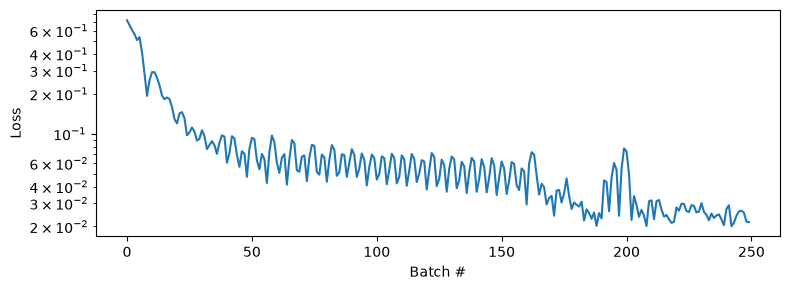

In [24]:
def plot_training_log(log):
  fig, axs = plt.subplots(1, 1)
  fig.set_tight_layout(True)
  fig.set_size_inches((8, 3))

  axs.semilogy(log)

  axs.set_ylabel("Loss")
  axs.set_xlabel("Batch #")
  plt.show()

plot_training_log(losses_gru)

#### Model Evaluation

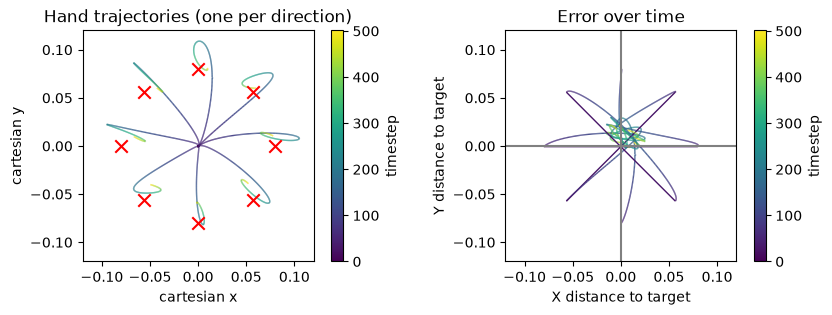

In [25]:
# ============================================================
# AFTER-TRAINING evaluation: did the POLICY learn to reach?
# Deterministic, one trial per direction, noise off.
# ============================================================

plotor = mn.plotor.plot_pos_over_time
with torch.no_grad():
    h = policy.init_hidden(batch_size=env.n_directions)
    obs, info = env.reset(options={
        "batch_size": env.n_directions,
        "direction_idx": np.arange(env.n_directions),
        "deterministic": True,
    })
    terminated = False
    xy_eval = [info["states"]["fingertip"][:, None, :]]
    tg_eval = [info["goal"][:, None, :]]

    while not terminated:
        action, h = policy(obs, h)
        obs, reward, terminated, truncated, info = env.step(action=action, deterministic=True)
        xy_eval.append(info["states"]["fingertip"][:, None, :])
        tg_eval.append(info["goal"][:, None, :])

    xy_eval = torch.detach(torch.cat(xy_eval, axis=1)).detach().cpu()
    tg_eval = torch.detach(torch.cat(tg_eval, axis=1)).detach().cpu()


lim = env.reaching_distance * 1.5
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.ylim([-lim, lim])
plt.xlim([-lim, lim])
plotor(axis=plt.gca(), cart_results=xy_eval)
plt.scatter(tg_eval[:, -1, 0], tg_eval[:, -1, 1], c="red", marker="x", s=80, zorder=5)
plt.title("Hand trajectories (one per direction)")

plt.subplot(1, 2, 2)
plt.ylim([-lim, lim])
plt.xlim([-lim, lim])
plotor(axis=plt.gca(), cart_results=xy_eval - tg_eval)
plt.axhline(0, c="grey")
plt.axvline(0, c="grey")
plt.xlabel("X distance to target")
plt.ylabel("Y distance to target")
plt.title("Error over time")

plt.show()

##### -Hand Trajectories of our effector from the centre to target at the end of episodes with respect to time.

##### -Error over time computes the error in position of the effector with respect to true target position for the centre out task for an episode.


In [27]:
# ============================================================
# Collect hidden-layer activity over time (one trial per fixed direction),
# packaged as a saveable bundle -- not just a plot.
# ============================================================
def collect_hidden_activity(env, policy, direction_idx=None, deterministic=True):
    if direction_idx is None:
        direction_idx = np.arange(env.n_directions)
    batch_size = len(np.atleast_1d(direction_idx))

    with torch.no_grad():
        h = policy.init_hidden(batch_size=batch_size)
        obs, info = env.reset(options={
            "batch_size": batch_size,
            "direction_idx": direction_idx,
            "deterministic": deterministic,
        })
        go_cue_time = info["go_cue_time"] ##
        direction_labels = info["direction_idx"]
        is_catch = info["is_catch"]
        terminated = False

        h_trace = [h.squeeze(0).detach().cpu().numpy().copy()]
        xy_trace = [info["states"]["fingertip"][:, None, :]]
        goal_trace = [info["goal"][:, None, :]]

        while not terminated:
            action, h = policy(obs, h)
            obs, reward, terminated, truncated, info = env.step(action=action, deterministic=deterministic)
            h_trace.append(h.squeeze(0).detach().cpu().numpy().copy())
            xy_trace.append(info["states"]["fingertip"][:, None, :])
            goal_trace.append(info["goal"][:, None, :])

    h_trace = np.stack(h_trace, axis=1)                                  # (batch, time, hidden_dim)
    xy_trace = torch.cat(xy_trace, dim=1).detach().cpu().numpy()         # (batch, time, 2)
    goal_trace = torch.cat(goal_trace, dim=1).detach().cpu().numpy()     # (batch, time, 2)

    return {
        "h_trace": h_trace,               # (batch, time, hidden_dim)
        "xy_trace": xy_trace,             # (batch, time, 2)
        "goal_trace": goal_trace,         # (batch, time, 2)
        "go_cue_time": go_cue_time,       # (batch,)
        "direction_idx": direction_labels,# (batch,)
        "is_catch": is_catch,             # (batch,)
        "dt": np.array(env.dt),
    }


def save_hidden_activity(data, path):
    np.savez(path, **data)
    print(f"Saved to {path}")


def load_hidden_activity(path="hidden_activity.npz"):
    npz = np.load(path)
    return {k: npz[k] for k in npz.files}


data = collect_hidden_activity(env, policy)
save_hidden_activity(data, "hidden_activity_CB.npz")
print("h_trace shape:", data["h_trace"].shape)   # (8, n_timesteps, 32)

Saved to hidden_activity_CB.npz
h_trace shape: (8, 502, 32)


In [37]:
def plot_hidden_units_over_time(data, trial=0, units=None, ax=None, legend_max=10):
    """
    Line plot of hidden-unit activation vs. time, for one trial (= one direction).

    units: None -> all hidden units; int -> single unit; list/array -> a subset.
    A dashed vertical line marks that trial's actual go-cue time.
    """
    h = data["h_trace"][trial]          # (time, hidden_dim)
    dt = float(data["dt"])
    times = np.arange(h.shape[0]) * dt
    hidden_dim = h.shape[1]

    if units is None:
        units = np.arange(hidden_dim)
    elif np.isscalar(units):
        units = [units]
    units = np.asarray(units)

    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(8, 4.5))

    if len(units) <= legend_max:
        for u in units:
            ax.plot(times, h[:, u], label=f"unit {u}")
        ax.legend(fontsize=8, ncol=2)
    else:
        colors = plt.cm.viridis(np.linspace(0, 1, len(units)))
        for u, c in zip(units, colors):
            ax.plot(times, h[:, u], color=c, lw=0.8, alpha=0.8)
        sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(units.min(), units.max()))
        plt.colorbar(sm, ax=ax, label="hidden unit index")

    ax.axvline(data["go_cue_time"][trial], ls="--", c="k", lw=1.2, label="go cue")
    if len(units) <= legend_max:
        ax.legend(fontsize=8, ncol=2)

    dir_idx = int(data["direction_idx"][trial])
    catch_str = " (CATCH TRIAL)" if data["is_catch"][trial] else ""
    ax.set_xlabel("time (s)")
    ax.set_ylabel("hidden unit activation")
    ax.set_title(f"Trial {trial} — direction {dir_idx}{catch_str}")

    if own_ax:
        plt.tight_layout()
        plt.show()

TypeError: 'float' object is not subscriptable

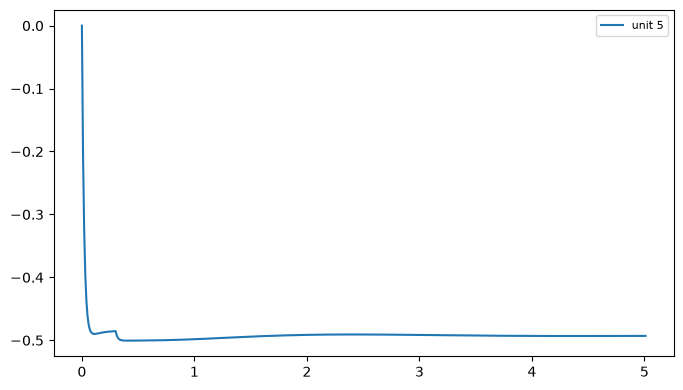

In [38]:
# a single unit, direction 0
plot_hidden_units_over_time(data, trial=0, units=5)

# a handful of units, direction 3
plot_hidden_units_over_time(data, trial=3, units=[0, 5, 12, 20])

# all 32 units at once, direction 0
plot_hidden_units_over_time(data, trial=0, units=None)

In [39]:
assert 1 == 2, "We break here"

AssertionError: We break here

## Dale's Backprop

In [40]:
def make_dale_sign(hidden_dim, frac_ex=0.8):
    """+1 = excitatory unit (all outgoing weights >= 0), -1 = inhibitory (<= 0)"""
    n_ex = int(hidden_dim * frac_ex)
    sign = torch.ones(hidden_dim)
    sign[n_ex:] = -1.0
    return sign

def dale_init_weight_hh(hidden_dim, sign, n_gates=3):
    """Matches nn.GRU weight_hh_l0 shape: (n_gates*hidden_dim, hidden_dim)"""
    limit = 1.0 / (hidden_dim ** 0.5)
    W = torch.empty(n_gates * hidden_dim, hidden_dim).uniform_(0, limit)
    W = W * sign[None, :]          # flips columns assigned -1 to be <= 0
    return W

def apply_dale_mask(W, sign):
    """In-place projection: zero any weight whose sign violates its column's assignment."""
    mask = torch.where(sign > 0, (W > 0).float(), (W < 0).float())
    W.mul_(mask)


#### Model Setup

In [41]:
hidden_dim = 32
frac_ex = 0.8

policy = Policy(env.observation_space.shape[0], hidden_dim, env.n_muscles, device=device)
optimizer = torch.optim.Adam(policy.parameters(), lr=10**-3)

dale_sign = make_dale_sign(hidden_dim, frac_ex).to(device)
with torch.no_grad():
    policy.gru.weight_hh_l0.copy_(
        dale_init_weight_hh(hidden_dim, dale_sign).to(device)
    )

In [42]:
# --- training loop ---
batch_size = 32
n_batch = 1000
losses_dale_gru = []
interval = 250

def l1(x, y):
  """L1 loss"""
  return torch.mean(torch.sum(torch.abs(x - y), dim=-1))

for batch in range(n_batch):
  # initialize batch
  h = policy.init_hidden(batch_size=batch_size)
  obs, info = env.reset(options={"batch_size": batch_size})

  terminated = False

  # initial positions and targets
  xy = [info["states"]["fingertip"][:, None, :]]
  tg = [info["goal"][:, None, :]]

  # simulate whole episode
  while not terminated:  # will run until `max_ep_duration` is reached
    action, h = policy(obs, h)
    obs, reward, terminated, truncated, info = env.step(action=action)

    xy.append(info["states"]["fingertip"][:, None, :])  # trajectories
    tg.append(info["goal"][:, None, :])  # targets

  # concatenate into a (batch_size, n_timesteps, xy) tensor
  xy = torch.cat(xy, axis=1)
  tg = torch.cat(tg, axis=1)
  loss = l1(xy, tg)  # L1 loss on position

  # backward pass & update weights
  optimizer.zero_grad()
  loss.backward()
  nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.)  # important!
  optimizer.step()

  with torch.no_grad():
      apply_dale_mask(policy.gru.weight_hh_l0.data, dale_sign)   # Dale's backprop

  losses_dale_gru.append(loss.item())

  if (batch % interval == 0) and (batch != 0):
    print("Batch {}/{} Done, mean policy loss: {}".format(batch, n_batch, sum(losses_dale_gru[-interval:])/interval))

Batch 250/1000 Done, mean policy loss: 0.24835933539271354
Batch 500/1000 Done, mean policy loss: 0.048858593210577964
Batch 750/1000 Done, mean policy loss: 0.028936639286577703


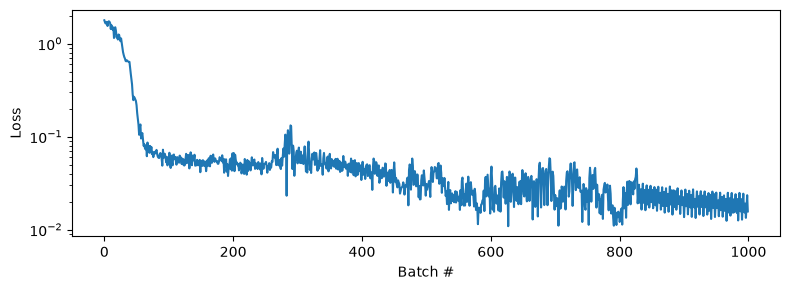

In [43]:
plot_training_log(losses_dale_gru)_

### Model Evaluation

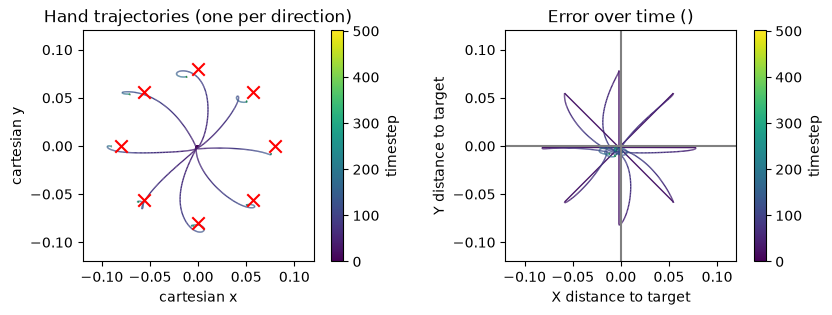

In [44]:
# ============================================================
# AFTER-TRAINING evaluation: did the POLICY learn to reach?
# Deterministic, one trial per direction, noise off.
# ============================================================

plotor = mn.plotor.plot_pos_over_time
with torch.no_grad():
    h = policy.init_hidden(batch_size=env.n_directions)
    obs, info = env.reset(options={
        "batch_size": env.n_directions,
        "direction_idx": np.arange(env.n_directions),
        "deterministic": True,
    })
    terminated = False
    xy_eval = [info["states"]["fingertip"][:, None, :]]
    tg_eval = [info["goal"][:, None, :]]

    while not terminated:
        action, h = policy(obs, h)
        obs, reward, terminated, truncated, info = env.step(action=action, deterministic=True)
        xy_eval.append(info["states"]["fingertip"][:, None, :])
        tg_eval.append(info["goal"][:, None, :])

    xy_eval = torch.detach(torch.cat(xy_eval, axis=1))
    tg_eval = torch.detach(torch.cat(tg_eval, axis=1))


lim = env.reaching_distance * 1.5
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.ylim([-lim, lim])
plt.xlim([-lim, lim])
plotor(axis=plt.gca(), cart_results=xy_eval)
plt.scatter(tg_eval[:, -1, 0], tg_eval[:, -1, 1], c="red", marker="x", s=80, zorder=5)
plt.title("Hand trajectories (one per direction)")

plt.subplot(1, 2, 2)
plt.ylim([-lim, lim])
plt.xlim([-lim, lim])
plotor(axis=plt.gca(), cart_results=xy_eval - tg_eval)
plt.axhline(0, c="grey")
plt.axvline(0, c="grey")
plt.xlabel("X distance to target")
plt.ylabel("Y distance to target")
plt.title("Error over time ()")

plt.show()

In [45]:
data = collect_hidden_activity(env, policy)
#save_hidden_activity(data, "hidden_activity.npz")
print("h_trace shape:", data["h_trace"].shape)


h_trace shape: (8, 502, 32)


TypeError: 'float' object is not subscriptable

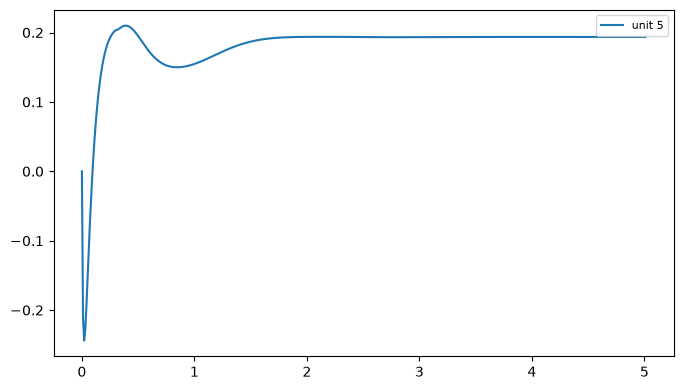

In [46]:
# a single unit, direction 0
plot_hidden_units_over_time(data, trial=0, units=5)

# a handful of units, direction 3
plot_hidden_units_over_time(data, trial=3, units=[0, 5, 12, 20])

# all 32 units at once, direction 0
plot_hidden_units_over_time(data, trial=0, units=None)

In [47]:
save_hidden_activity(data, "hidden_activity_dale.npz")

Saved to hidden_activity_dale.npz
